<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22313966/IMDB_RNN_IT22313966.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# -------------------------------
# 1) Imports, seeds, and globals
# -------------------------------

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, GlobalMaxPooling1D, SpatialDropout1D, BatchNormalization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# -------------------------
# Reproducibility / config
# -------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyperparameters (tweakable)
MAX_FEATURES = 10000    # vocabulary size (num_words for imdb.load_data)
MAXLEN = 300            # sequence length (truncate/pad)
EMBED_DIM = 100
RNN_UNITS = 64          # moderate size to avoid overfitting
BATCH_SIZE = 32         # smaller batches often generalize better
EPOCHS = 15

#MODEL_DIR = "models"
#MODEL_PATH = os.path.join(MODEL_DIR, "rnn_imdb_best.h5")

os.makedirs(MODEL_DIR, exist_ok=True)

In [32]:
# -----------------------------------------
# 2) Data loading and preprocessing (Keras)
# -----------------------------------------
print("Loading IMDB data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

# Get the word index and save it for later use
word_index = imdb.get_word_index()
# Add 3 for the special tokens <pad>, <start>, <unknown>
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["<pad>"] = 0
word_index["<start>"] = 1
word_index["<unknown>"] = 2
# Reverse the word index to get the mapping from index to word
index_word = dict([(value, key) for (key, value) in word_index.items()])

# Decode an example review (optional)
# def decode_review(text):
#     return ' '.join([index_word.get(i, '?') for i in text])

# print("Decoded example review:", decode_review(x_train[0]))


# Pad / truncate sequences
x_train = pad_sequences(x_train, maxlen=MAXLEN, padding='pre', truncating='pre')
x_test  = pad_sequences(x_test,  maxlen=MAXLEN, padding='pre', truncating='pre')

# Create a validation set from training data (keep holdout)
VAL_SAMPLES = 5000
x_val = x_train[-VAL_SAMPLES:]
y_val = y_train[-VAL_SAMPLES:]
x_train = x_train[:-VAL_SAMPLES]
y_train = y_train[:-VAL_SAMPLES]

print("Shapes: x_train", x_train.shape, "x_val", x_val.shape, "x_test", x_test.shape)

Loading IMDB data...
Shapes: x_train (20000, 300) x_val (5000, 300) x_test (25000, 300)


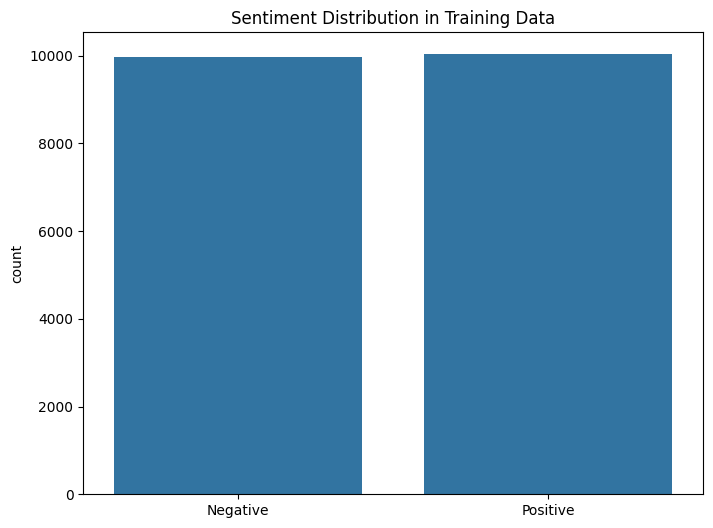

In [33]:
# Count plot for positive and negative reviews
plt.figure(figsize=(8,6))
# Corrected to use the loaded training labels
sns.countplot(x=y_train)
plt.title('Sentiment Distribution in Training Data')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [34]:
# Build RNN-only model
# -------------------------
def build_rnn_model(max_features=MAX_FEATURES, embed_dim=EMBED_DIM, rnn_units=RNN_UNITS, maxlen=MAXLEN, dropout_rate=0.3, l2_reg=1e-3):
    """
    RNN-only model: Embedding -> SpatialDropout1D -> SimpleRNN(return_sequences=True, recurrent_dropout)
                    -> GlobalMaxPooling1D -> Dense (with BatchNorm & Dropout) -> Output(sigmoid)
    Regularized for better generalization.
    """
    model = Sequential()
    # Embedding (trainable)
    model.add(Embedding(input_dim=max_features, output_dim=embed_dim))  # input_length not required; will be inferred
    # SpatialDropout on embedding channels (regularize embeddings)
    model.add(SpatialDropout1D(0.2))
    # SimpleRNN stacked (first returns sequences so pooling sees full sequence)
    model.add(SimpleRNN(rnn_units, return_sequences=True,
                        kernel_regularizer=l2(l2_reg),
                        recurrent_dropout=0.2))  # recurrent_dropout regularizes temporal connections
    # Pooling -> reduces sequence dimension robustly (keeps strongest activations)
    model.add(GlobalMaxPooling1D())
    # Dense block with regularization
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    # Output
    model.add(Dense(1, activation='sigmoid'))
    return model

print("Building RNN model...")
# Check if model exists and load it
if os.path.exists(MODEL_PATH):
    print("Loading existing model...")
    model = load_model(MODEL_PATH)
else:
    print("Building new model...")
    model = build_rnn_model()
    # Build model (so summary shows correct param counts)
    model.build(input_shape=(None, MAXLEN))

model.summary()

Building RNN model...
Loading existing model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 300, 64)        │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,015,043 (3.87 MB)

 Trainable params: 1,014,913 (3.87 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 2 (12.00 B)

In [35]:
# -------------------------
# Compile & callbacks
# -------------------------
optimizer = Adam(learning_rate=1e-3, clipnorm=1.0)  # clipnorm stabilizes training
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
checkpoint = ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)

In [36]:
# -------------------------
# Train
# -------------------------
print("Training the model...")
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1,
    shuffle=True
)

Training the model...
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5014 - loss: 0.6929
Epoch 1: val_loss improved from inf to 0.61932, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 129ms/step - accuracy: 0.5014 - loss: 0.6929 - val_accuracy: 0.6706 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6520 - loss: 0.6280
Epoch 2: val_loss improved from 0.61932 to 0.57733, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 121ms/step - accuracy: 0.6520 - loss: 0.6280 - val_accuracy: 0.7184 - val_loss: 0.5773 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7108 - loss: 0.5879
Epoch 3: val_loss improved from 0.57733 to 0.51767, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.7108 - loss: 0.5879 - val_accuracy: 0.7648 - val_loss: 0.5177 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7530 - loss: 0.5337
Epoch 4: val_loss improved from 0.51767 to 0.48611, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.7530 - loss: 0.5337 - val_accuracy: 0.7838 - val_loss: 0.4861 - learning_rate: 0.0010
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.7803 - loss: 0.4869
Epoch 5: val_loss improved from 0.48611 to 0.47530, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.7803 - loss: 0.4869 - val_accuracy: 0.7864 - val_loss: 0.4753 - learning_rate: 0.0010
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7954 - loss: 0.4618
Epoch 6: val_loss improved from 0.47530 to 0.47193, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.7955 - loss: 0.4617 - val_accuracy: 0.7940 - val_loss: 0.4719 - learning_rate: 0.0010
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8048 - loss: 0.4520
Epoch 7: val_loss improved from 0.47193 to 0.45595, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.8048 - loss: 0.4520 - val_accuracy: 0.8034 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8287 - loss: 0.4181
Epoch 8: val_loss improved from 0.45595 to 0.43705, saving model to models/rnn_imdb_best.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.8287 - loss: 0.4180 - val_accuracy: 0.8134 - val_loss: 0.4370 - learning_rate: 0.0010
Epoch 9/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8446 - loss: 0.3836
Epoch 9: val_loss did not improve from 0.43705
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.8446 - loss: 0.3836 - val_accuracy: 0.8170 - val_loss: 0.4398 - learning_rate: 0.0010
Epoch 10/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8626 - loss: 0.3535
Epoch 10: val_loss did not improve from 0.43705
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 109ms/step - accuracy: 0.8626 - loss: 0.3535 - val_accuracy: 0.8218 - val_loss: 0.4471 - learning_rate: 0.0010
Epoch 11/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8799 - loss: 0.3188
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: val_loss did not improve from 0.43705
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.8799 - loss: 0.3188 - v

In [38]:
# Save the trained model for later use
model_path = os.path.join(MODEL_DIR, "imdb_rnn_model.h5")
model.save(model_path)
print(f"Saved model to: {model_path}")

Saved model to: models/imdb_rnn_model.h5


In [39]:
# load the model from the checkpoint
model = load_model('models/imdb_rnn_model.h5')

In [40]:
# Evaluate on test set
# -------------------------
val_probs = model.predict(x_val, batch_size=128).flatten()
test_probs = model.predict(x_test, batch_size=128).flatten()

# Tune threshold on validation set by maximizing F1
from sklearn.metrics import f1_score
ths = np.linspace(0.1, 0.9, 81)
best_thr = 0.5
best_f1 = -1.0
for thr in ths:
    preds = (val_probs > thr).astype(int)
    f = f1_score(y_val, preds)
    if f > best_f1:
        best_f1 = f
        best_thr = thr
print(f"Best validation threshold by F1: {best_thr:.3f} (F1={best_f1:.4f})")

# Evaluate on test set using tuned threshold
y_test_pred = (test_probs > best_thr).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Test Accuracy:  {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall:    {rec:.4f}")
print(f"Test F1:        {f1:.4f}")

print("\nClassification report:\n", classification_report(y_test, y_test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step
Best validation threshold by F1: 0.370 (F1=0.8181)
Test Accuracy:  0.8131
Test Precision: 0.7941
Test Recall:    0.8453
Test F1:        0.8189

Classification report:
               precision    recall  f1-score   support

           0     0.8346    0.7809    0.8069     12500
           1     0.7941    0.8453    0.8189     12500

    accuracy                         0.8131     25000
   macro avg     0.8144    0.8131    0.8129     25000
weighted avg     0.8144    0.8131    0.8129     25000

Confusion matrix:
 [[ 9761  2739]
 [ 1934 10566]]


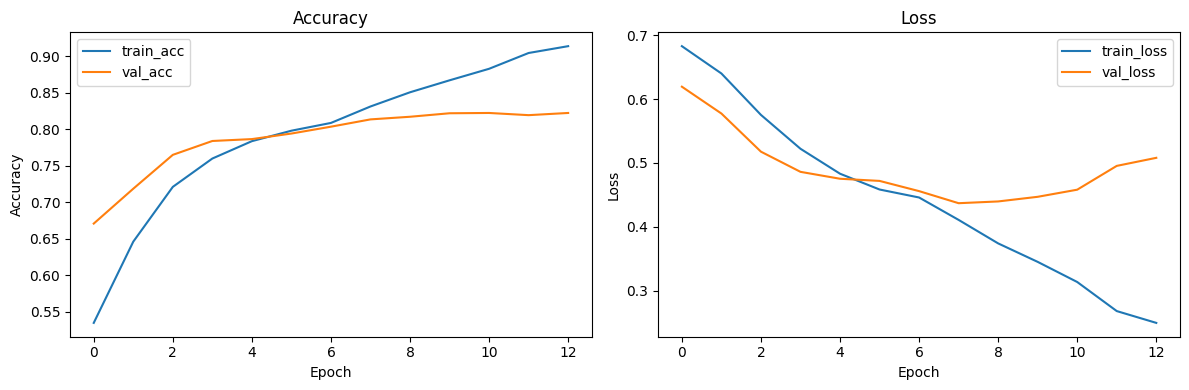

In [41]:
# -------------------------
# Plot training curves
# -------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history.get('accuracy', []), label='train_acc')
plt.plot(history.history.get('val_accuracy', []), label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

In [42]:
final_model_path = os.path.join(MODEL_DIR, "rnn_imdb_final.h5")
model.save(final_model_path)
print(f"Saved final model to {final_model_path}")

Saved final model to models/rnn_imdb_final.h5


In [43]:
with open(os.path.join(MODEL_DIR, "best_threshold.txt"), "w") as f:
    f.write(str(best_thr))


In [49]:
# -----------------------------------------
# 6) Inference on new text data
# -----------------------------------------
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the word index saved during data preprocessing
word_index = imdb.get_word_index()
word_index = {k:(v+3) for k,v in word_index.items()}
word_index["<pad>"] = 0
word_index["<start>"] = 1
word_index["<unknown>"] = 2

# Create a tokenizer from the loaded word index
tokenizer = Tokenizer(num_words=MAX_FEATURES)
tokenizer.word_index = word_index

# Load best threshold (if available)
best_threshold_path = os.path.join(MODEL_DIR, "best_threshold.txt")
try:
    with open(best_threshold_path, "r") as f:
        best_threshold = float(f.read().strip())
except Exception:
    best_threshold = 0.5  # default fallback
print(f"Using prediction threshold: {best_threshold:.3f}")


# Preprocess and tokenize review
def preprocess_review(text, maxlen=MAXLEN):
    """Clean and convert review text to a padded sequence."""
    text = re.sub(r"<.*?>", " ", text)           # remove HTML tags
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)   # remove punctuation
    text = text.lower().strip()
    seq = tokenizer.texts_to_sequences([text])
    return pad_sequences(seq, maxlen=maxlen, padding="pre", truncating="pre")

# Predict sentiment
def predict_sentiment(review):
    """Predict sentiment for a single review."""
    seq = preprocess_review(review)
    prob = float(model.predict(seq, verbose=0)[0][0])
    label = "Positive 😀" if prob > best_threshold else "Negative 😞"
    return f"{label} (prob={prob:.4f}, threshold={best_threshold:.3f})"

# Example usage
example_review = "Movie is good but actors acted not well"
print("Example prediction:", predict_sentiment(example_review))

Using prediction threshold: 0.370
Example prediction: Positive 😀 (prob=0.8445, threshold=0.370)


In [48]:
# Example usage
example_review = "Movie is not bad but actors acted badly"
print("Example prediction:", predict_sentiment(example_review))

Example prediction: Negative 😞 (prob=0.3352, threshold=0.370)


In [50]:
# Example usage
example_review = "Movie is too long but nice"
print("Example prediction:", predict_sentiment(example_review))

Example prediction: Positive 😀 (prob=0.7470, threshold=0.370)


In [51]:
# Example usage
example_review = "Film was boring"
print("Example prediction:", predict_sentiment(example_review))

Example prediction: Negative 😞 (prob=0.0634, threshold=0.370)
